# Multivariate Time Series Visualization

这个 notebook 按照下面的结构理解 CSV：

- 行数 `3000`：时间点 / 样本顺序；
- 列数 `144`：变量数；
- 因此数据形状是 `[time_steps, num_variables]`。

也就是说，正确画法应该是：

- 画某几个变量随时间变化：`df.iloc[:, variable_id]`
- 横轴是时间索引；
- 纵轴是变量值；
- 变量编号是列索引。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.unicode_minus"] = False

## 1. 读取数据

In [2]:
CSV_PATH = "datasets/Seattle/Seattle.csv"

if not Path(CSV_PATH).exists():
    csv_files = list(Path(".").glob("*.csv"))
    if len(csv_files) == 0:
        raise FileNotFoundError("当前目录没有找到 CSV 文件，请检查 CSV_PATH。")
    CSV_PATH = str(csv_files[0])
    print(f"未找到指定文件，自动使用: {CSV_PATH}")

df = pd.read_csv(CSV_PATH, header=None)
df = df.apply(pd.to_numeric, errors="coerce")

data = df.values.astype(float)

num_time_steps, num_variables = data.shape

print("CSV 文件:", CSV_PATH)
print("数据形状:", data.shape)
print("时间点数量 num_time_steps:", num_time_steps)
print("变量数量 num_variables:", num_variables)
print("缺失值数量:", df.isna().sum().sum())

display(df.head())

CSV 文件: datasets/Seattle/Seattle.csv
数据形状: (688, 9801)
时间点数量 num_time_steps: 688
变量数量 num_variables: 9801
缺失值数量: 0


,0,1,2,3,4,5,6,7,8,9,...,9791,9792,9793,9794,9795,9796,9797,9798,9799,9800
0,0,0.17,0.32,0.44,0.02,0.30,0.00,0.14,0.10,0.12,...,0.49,0.22,0.09,0.59,1.01,0.24,0.19,0.43,0.19,0.01
1,0,0.18,0.15,0.16,0.02,0.32,0.01,0.14,0.31,0.12,...,0.49,0.22,0.09,0.59,1.01,0.24,0.19,0.43,0.19,0.01
2,0,0.18,0.15,0.16,0.02,0.32,0.01,0.14,0.31,0.12,...,0.20,0.22,0.43,0.27,0.12,0.31,0.49,0.22,0.19,0.02
3,0,0.18,0.15,0.16,0.02,0.32,0.01,0.14,0.31,0.12,...,0.20,0.22,0.43,0.27,0.12,0.31,0.49,0.22,0.19,0.02
4,0,0.18,0.15,0.16,0.02,0.32,0.01,0.14,0.31,0.12,...,0.20,0.22,0.43,0.27,0.12,0.31,0.49,0.22,0.19,0.02


## 2. 基础统计

In [3]:
stats = {
    "num_time_steps": num_time_steps,
    "num_variables": num_variables,
    "min": np.nanmin(data),
    "max": np.nanmax(data),
    "mean": np.nanmean(data),
    "std": np.nanstd(data),
    "median": np.nanmedian(data),
    "q10": np.nanquantile(data, 0.10),
    "q25": np.nanquantile(data, 0.25),
    "q75": np.nanquantile(data, 0.75),
    "q90": np.nanquantile(data, 0.90),
    "q99": np.nanquantile(data, 0.99),
}

display(pd.DataFrame([stats]))

,num_time_steps,num_variables,min,max,mean,std,median,q10,q25,q75,q90,q99
0,688,9801,0.0,90.5,0.3625,0.897143,0.22,0.04,0.11,0.44,0.58,2.73


## 3. 随机选择变量，画变量随时间变化

这是最核心的图：每一条线是一列变量。

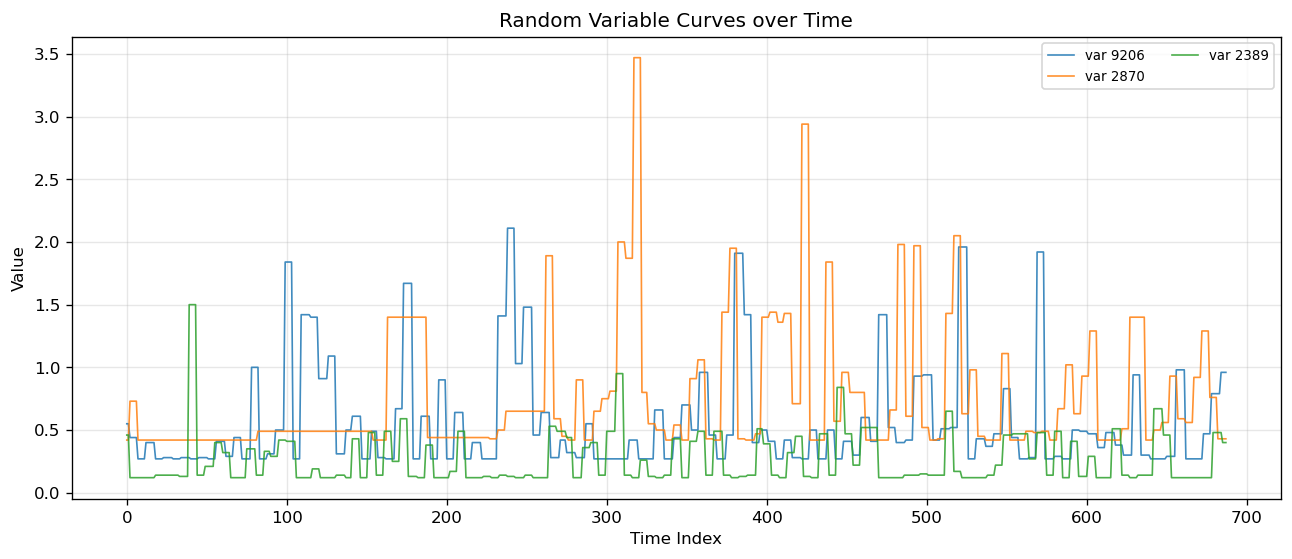

In [4]:
np.random.seed(2024)

num_vars_to_plot = min(3, num_variables)
var_ids = np.random.choice(num_variables, size=num_vars_to_plot, replace=False)

time_index = np.arange(num_time_steps)

plt.figure(figsize=(13, 5))

for vid in var_ids:
    plt.plot(time_index, data[:, vid], linewidth=1, alpha=0.85, label=f"var {vid}")

plt.title("Random Variable Curves over Time")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

## 4. 指定变量随时间变化

修改 `target_var_id` 可以查看某一个具体变量。

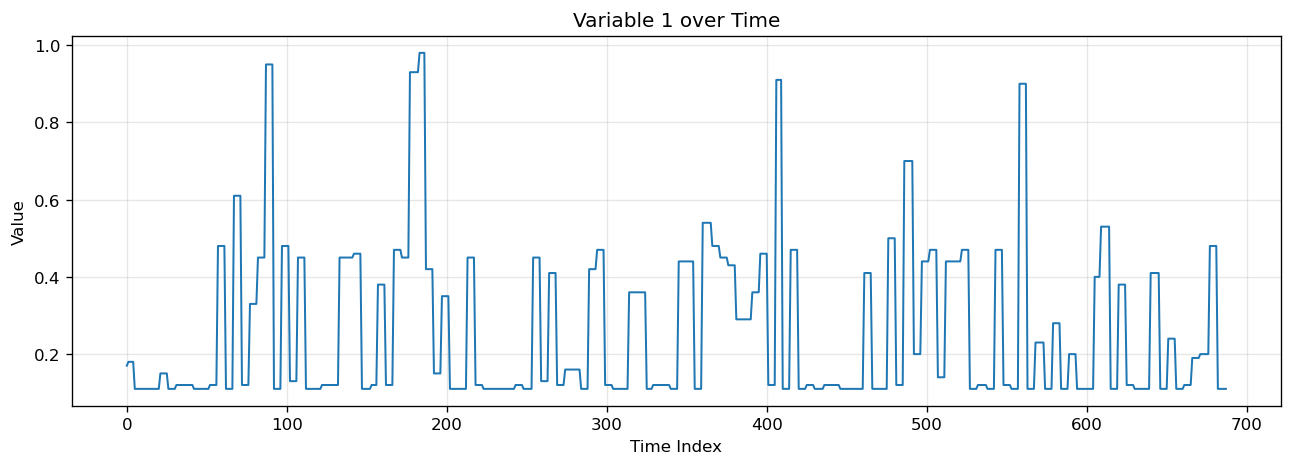

In [5]:
target_var_id = 1

plt.figure(figsize=(13, 4))

plt.plot(time_index, data[:, target_var_id], linewidth=1.2)

plt.title(f"Variable {target_var_id} over Time")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.show()

## 5. 局部时间窗口放大

如果全局曲线太密，可以指定一个时间段放大。

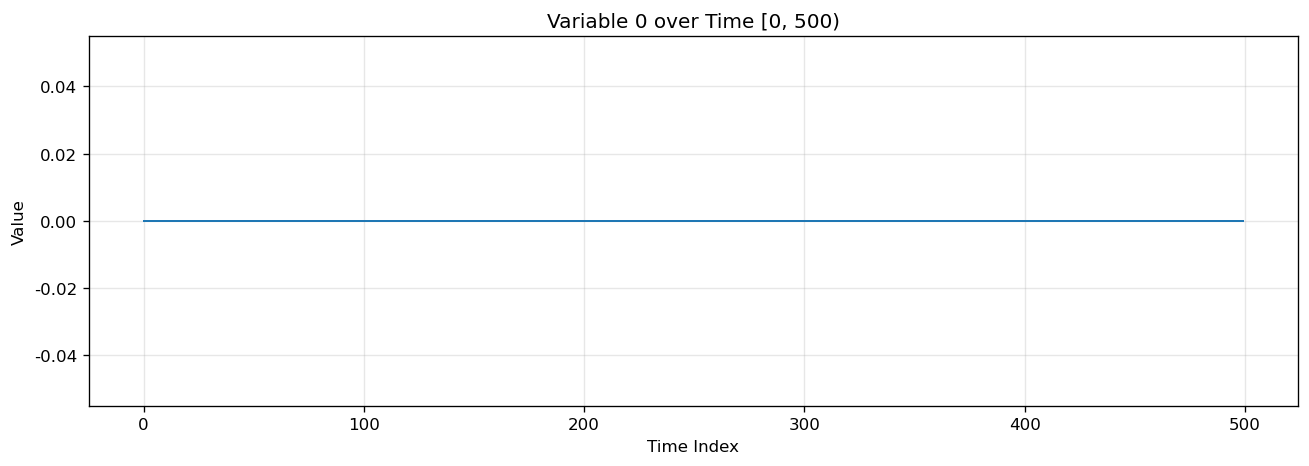

In [6]:
target_var_id = 0
start_idx = 0
end_idx = min(500, num_time_steps)

plt.figure(figsize=(13, 4))

plt.plot(
    time_index[start_idx:end_idx],
    data[start_idx:end_idx, target_var_id],
    linewidth=1.2,
)

plt.title(f"Variable {target_var_id} over Time [{start_idx}, {end_idx})")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.show()

## 6. 所有变量的均值趋势和波动范围

每个时间点上，对 144 个变量求均值和标准差。

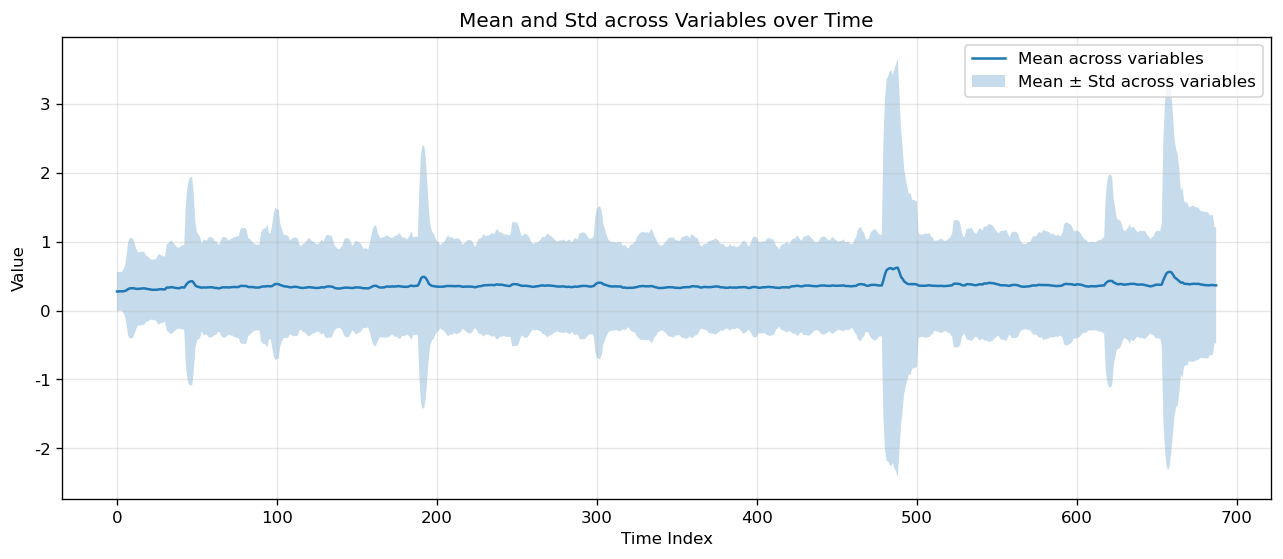

In [7]:
time_mean = np.nanmean(data, axis=1)
time_std = np.nanstd(data, axis=1)

plt.figure(figsize=(13, 5))

plt.plot(time_index, time_mean, linewidth=1.5, label="Mean across variables")
plt.fill_between(
    time_index,
    time_mean - time_std,
    time_mean + time_std,
    alpha=0.25,
    label="Mean ± Std across variables"
)

plt.title("Mean and Std across Variables over Time")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. 所有变量的中位数和分位数范围

相比均值和标准差，中位数与分位数对极端值更稳健。

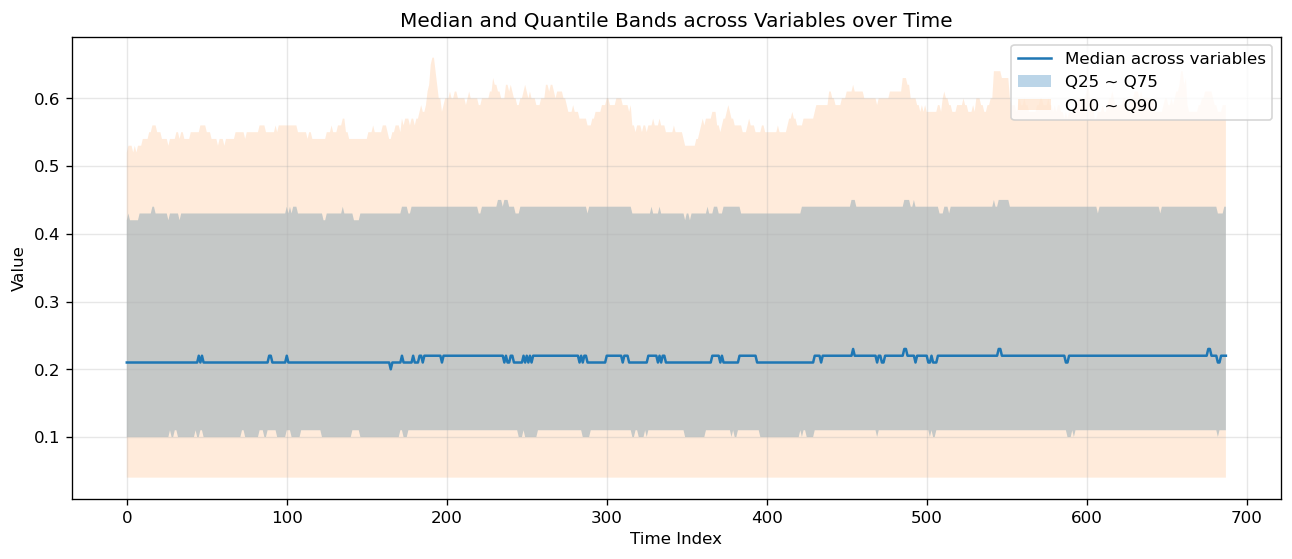

In [8]:
time_median = np.nanmedian(data, axis=1)
time_q25 = np.nanquantile(data, 0.25, axis=1)
time_q75 = np.nanquantile(data, 0.75, axis=1)
time_q10 = np.nanquantile(data, 0.10, axis=1)
time_q90 = np.nanquantile(data, 0.90, axis=1)

plt.figure(figsize=(13, 5))

plt.plot(time_index, time_median, linewidth=1.5, label="Median across variables")
plt.fill_between(time_index, time_q25, time_q75, alpha=0.30, label="Q25 ~ Q75")
plt.fill_between(time_index, time_q10, time_q90, alpha=0.15, label="Q10 ~ Q90")

plt.title("Median and Quantile Bands across Variables over Time")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. 原始数据热力图

横轴是变量，纵轴是时间。

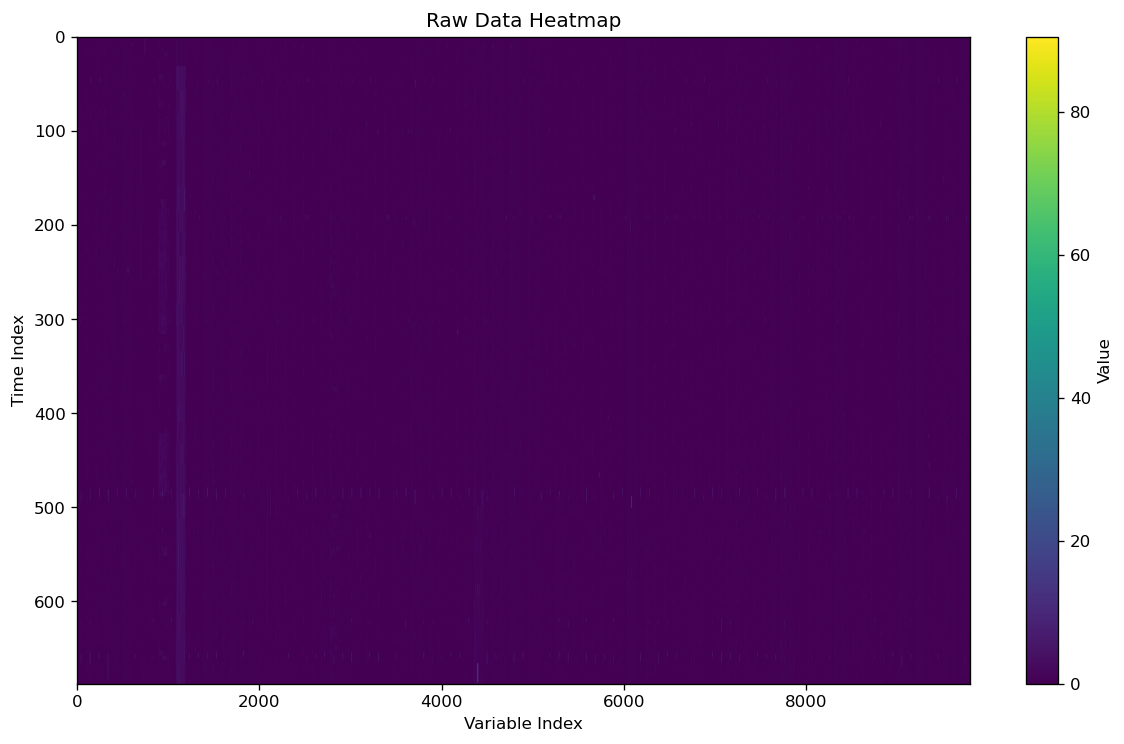

In [9]:
plt.figure(figsize=(12, 7))

plt.imshow(data, aspect="auto")
plt.colorbar(label="Value")

plt.title("Raw Data Heatmap")
plt.xlabel("Variable Index")
plt.ylabel("Time Index")
plt.show()

## 9. 按变量标准化后的热力图

不同变量量纲差异较大时，原始热力图可能被少数大值变量主导。  
这里对每个变量分别做 z-score 标准化，更适合观察变化模式。

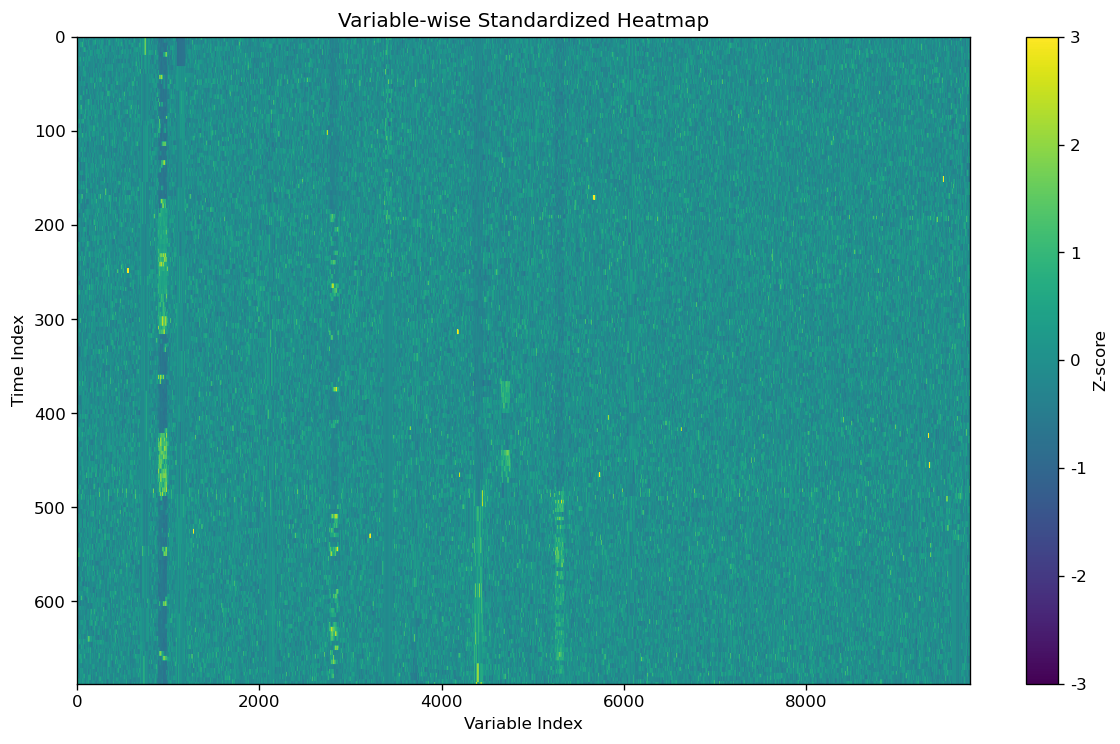

In [10]:
var_mean = np.nanmean(data, axis=0, keepdims=True)
var_std = np.nanstd(data, axis=0, keepdims=True)
data_z = (data - var_mean) / (var_std + 1e-8)

plt.figure(figsize=(12, 7))

plt.imshow(data_z, aspect="auto", vmin=-3, vmax=3)
plt.colorbar(label="Z-score")

plt.title("Variable-wise Standardized Heatmap")
plt.xlabel("Variable Index")
plt.ylabel("Time Index")
plt.show()

## 10. 每个变量的均值、标准差、最大值

用于判断哪些变量整体幅值更大、波动更强或者存在尖峰。

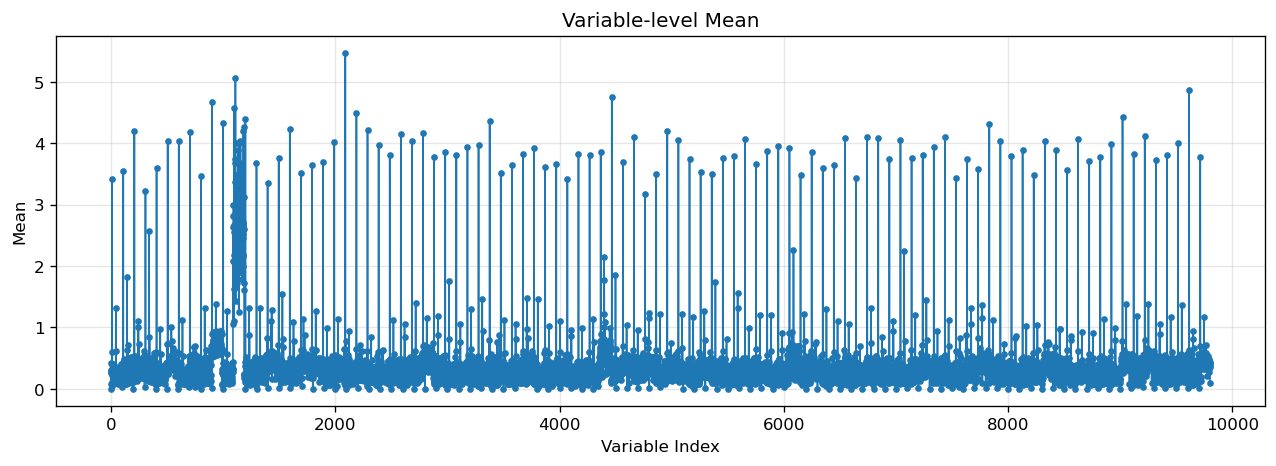

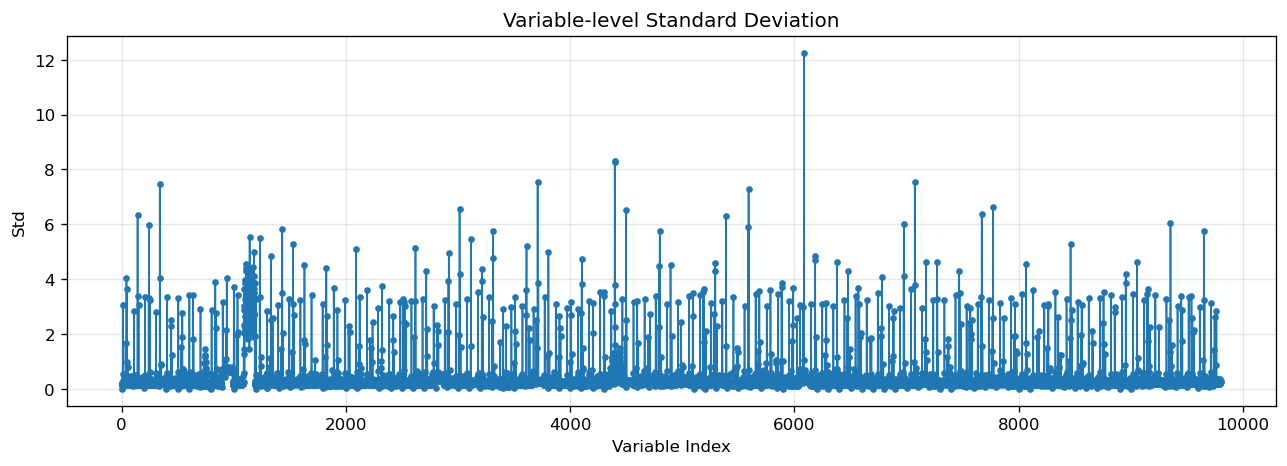

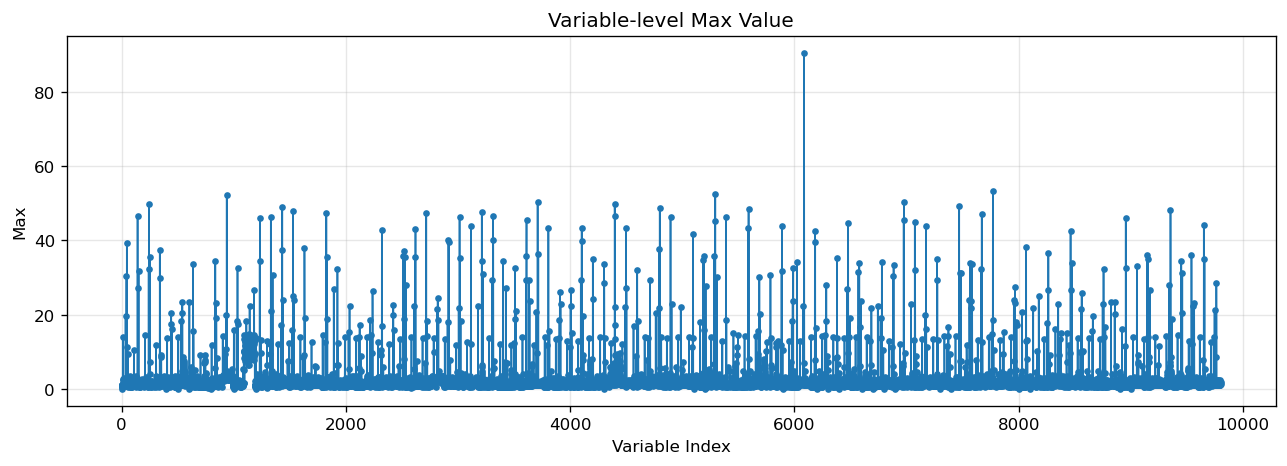

In [11]:
var_mean_1d = np.nanmean(data, axis=0)
var_std_1d = np.nanstd(data, axis=0)
var_max_1d = np.nanmax(data, axis=0)

var_index = np.arange(num_variables)

plt.figure(figsize=(13, 4))
plt.plot(var_index, var_mean_1d, marker="o", markersize=3, linewidth=1)
plt.title("Variable-level Mean")
plt.xlabel("Variable Index")
plt.ylabel("Mean")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(13, 4))
plt.plot(var_index, var_std_1d, marker="o", markersize=3, linewidth=1)
plt.title("Variable-level Standard Deviation")
plt.xlabel("Variable Index")
plt.ylabel("Std")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(13, 4))
plt.plot(var_index, var_max_1d, marker="o", markersize=3, linewidth=1)
plt.title("Variable-level Max Value")
plt.xlabel("Variable Index")
plt.ylabel("Max")
plt.grid(True, alpha=0.3)
plt.show()

## 11. 变量分布箱线图

每个箱子对应一个变量在 3000 个时间点上的分布。

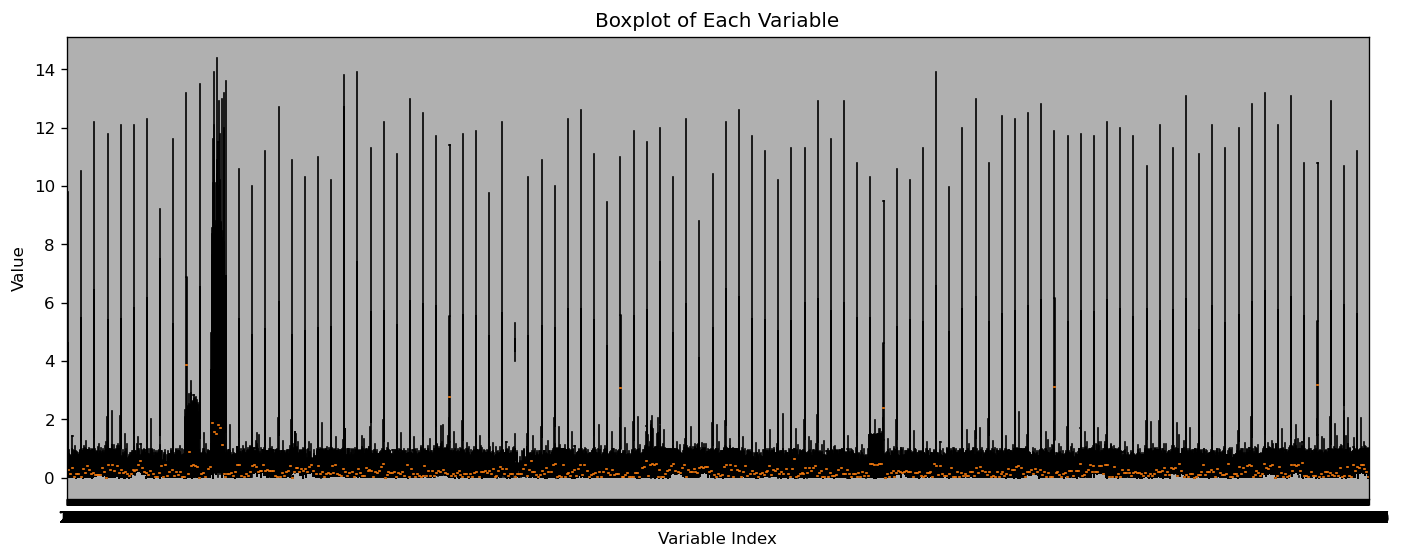

In [12]:
plt.figure(figsize=(14, 5))

plt.boxplot(data, showfliers=False)

plt.title("Boxplot of Each Variable")
plt.xlabel("Variable Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)

plt.show()

## 12. 变量相关性热力图

用于观察 144 个变量之间的相关性。

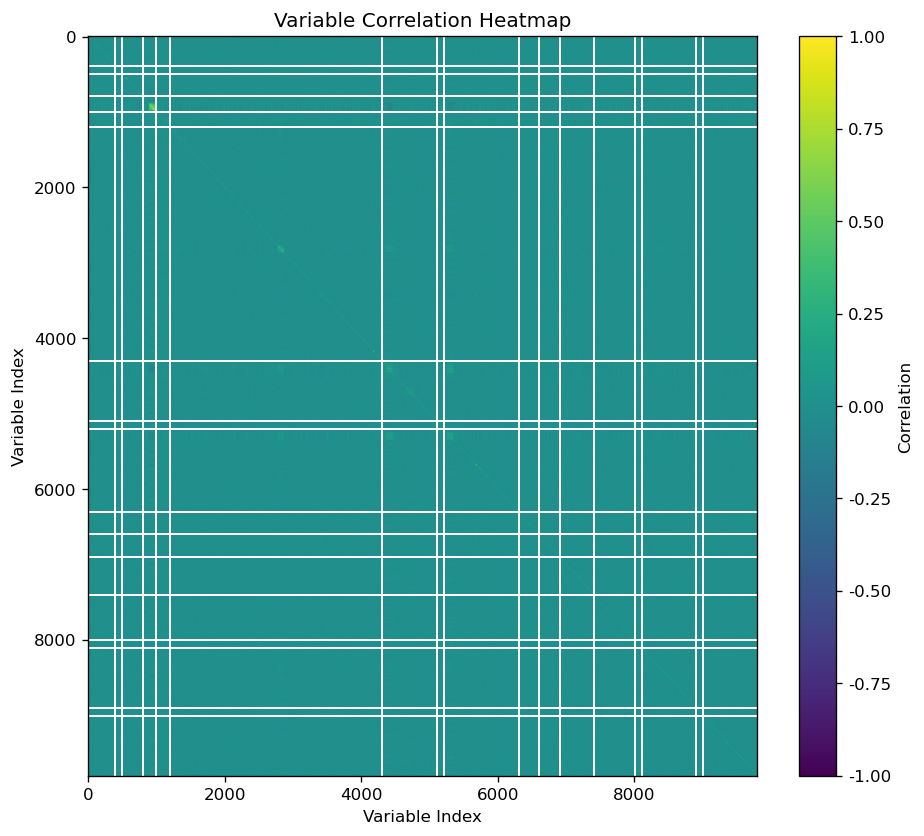

In [13]:
corr = df.corr()

plt.figure(figsize=(9, 8))

plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.title("Variable Correlation Heatmap")
plt.xlabel("Variable Index")
plt.ylabel("Variable Index")
plt.show()

## 13. PCA 二维可视化

每一个点是一个时间点，特征是 144 个变量。  
这个图可以观察时间点在多变量空间中是否存在状态分群。

PCA 解释方差比例: [0.02302687 0.01765586]
PCA 累计解释方差: 0.04068273338718676


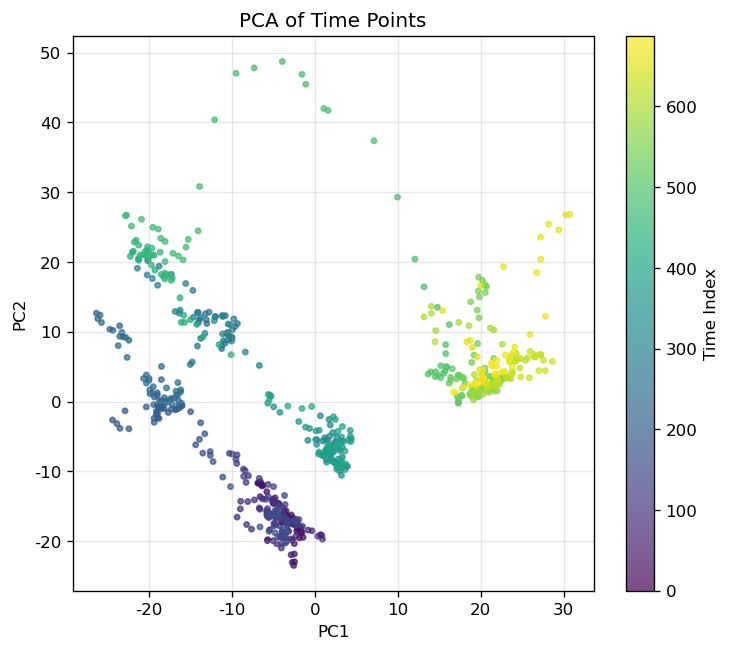

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_filled = df.copy()
df_filled = df_filled.fillna(df_filled.mean())

data_filled = df_filled.values.astype(float)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_filled)

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

print("PCA 解释方差比例:", pca.explained_variance_ratio_)
print("PCA 累计解释方差:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    data_pca[:, 0],
    data_pca[:, 1],
    s=10,
    alpha=0.7,
    c=time_index,
)

plt.colorbar(scatter, label="Time Index")

plt.title("PCA of Time Points")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

## 14. 保存关键图像

In [15]:
save_dir = Path("figures_multivariate_timeseries")
save_dir.mkdir(exist_ok=True)

# 1) 随机变量时间曲线
plt.figure(figsize=(13, 5))
for vid in var_ids:
    plt.plot(time_index, data[:, vid], linewidth=1, alpha=0.85, label=f"var {vid}")
plt.title("Random Variable Curves over Time")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "random_variable_curves_over_time.png")
plt.close()

# 2) 原始热力图
plt.figure(figsize=(12, 7))
plt.imshow(data, aspect="auto")
plt.colorbar(label="Value")
plt.title("Raw Data Heatmap")
plt.xlabel("Variable Index")
plt.ylabel("Time Index")
plt.tight_layout()
plt.savefig(save_dir / "raw_data_heatmap.png")
plt.close()

# 3) 标准化热力图
plt.figure(figsize=(12, 7))
plt.imshow(data_z, aspect="auto", vmin=-3, vmax=3)
plt.colorbar(label="Z-score")
plt.title("Variable-wise Standardized Heatmap")
plt.xlabel("Variable Index")
plt.ylabel("Time Index")
plt.tight_layout()
plt.savefig(save_dir / "standardized_heatmap.png")
plt.close()

# 4) 变量相关性
plt.figure(figsize=(9, 8))
plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Variable Correlation Heatmap")
plt.xlabel("Variable Index")
plt.ylabel("Variable Index")
plt.tight_layout()
plt.savefig(save_dir / "variable_correlation_heatmap.png")
plt.close()

# 5) PCA
plt.figure(figsize=(7, 6))
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], s=10, alpha=0.7, c=time_index)
plt.colorbar(scatter, label="Time Index")
plt.title("PCA of Time Points")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "pca_time_points.png")
plt.close()

print(f"关键图像已保存到: {save_dir.resolve()}")

关键图像已保存到: /home/xuke/mkw/Extreme/figures_multivariate_timeseries


## 15. 阅读顺序建议

建议优先看：

1. `Random Variable Curves over Time`：看变量随时间的变化；
2. `Raw Data Heatmap`：看全局时序-变量结构；
3. `Variable-wise Standardized Heatmap`：看去除量纲差异后的动态模式；
4. `Variable Correlation Heatmap`：看变量之间是否高度相关；
5. `PCA of Time Points`：看不同时间点是否存在状态分群。